Implement a Recurrent Neural Network model (Vanilla RNN, GRU, and LSTM) to predict whether a review is positive or negative.

Data: [IMDB Dataset of 50K Movie Reviews](https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews) (the last 10% of rows serve as the test set).
Compare the performance of the three models.

# Loading data

In [1]:
import os
import kagglehub

path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")
data_file_path = os.path.join(path, 'IMDB Dataset.csv')

Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.


In [2]:
import pandas as pd

df = pd.read_csv(data_file_path)
display(df.head())

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [3]:
df['review'][0]

"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fa

# EDA and preprocessing

In [4]:
import re
import nltk
from nltk.tokenize import word_tokenize
nltk.download('punkt')
nltk.download('punkt_tab')

def preprocess_text(text):
  text = re.sub(r'<.*?>', ' ', text)
  text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
  text = text.lower()
  tokens = word_tokenize(text)
  return tokens

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [5]:
preprocess_text(df['review'][0])

['one',
 'of',
 'the',
 'other',
 'reviewers',
 'has',
 'mentioned',
 'that',
 'after',
 'watching',
 'just',
 '1',
 'oz',
 'episode',
 'you',
 'll',
 'be',
 'hooked',
 'they',
 'are',
 'right',
 'as',
 'this',
 'is',
 'exactly',
 'what',
 'happened',
 'with',
 'me',
 'the',
 'first',
 'thing',
 'that',
 'struck',
 'me',
 'about',
 'oz',
 'was',
 'its',
 'brutality',
 'and',
 'unflinching',
 'scenes',
 'of',
 'violence',
 'which',
 'set',
 'in',
 'right',
 'from',
 'the',
 'word',
 'go',
 'trust',
 'me',
 'this',
 'is',
 'not',
 'a',
 'show',
 'for',
 'the',
 'faint',
 'hearted',
 'or',
 'timid',
 'this',
 'show',
 'pulls',
 'no',
 'punches',
 'with',
 'regards',
 'to',
 'drugs',
 'sex',
 'or',
 'violence',
 'its',
 'is',
 'hardcore',
 'in',
 'the',
 'classic',
 'use',
 'of',
 'the',
 'word',
 'it',
 'is',
 'called',
 'oz',
 'as',
 'that',
 'is',
 'the',
 'nickname',
 'given',
 'to',
 'the',
 'oswald',
 'maximum',
 'security',
 'state',
 'penitentary',
 'it',
 'focuses',
 'mainly',
 'o

In [6]:
import numpy as np

# Download GloVe embeddings
glove_path = kagglehub.dataset_download("danielwillgeorge/glove6b100dtxt")
glove_file = os.path.join(glove_path, 'glove.6B.100d.txt')

# Parse the file and create word_to_vec mapping
word_to_vec = {}
with open(glove_file, 'r', encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype='float32')
        word_to_vec[word] = vector

# Create word_to_idx mapping
# Index 0 for <pad>, Index 1 for <unk>
word_to_idx = {word: i + 2 for i, word in enumerate(word_to_vec.keys())}
word_to_idx['<pad>'] = 0
word_to_idx['<unk>'] = 1

print(f"Total vocabulary size (including special tokens): {len(word_to_idx)}")
print(f"Vector dimension: {next(iter(word_to_vec.values())).shape[0]}")

Using Colab cache for faster access to the 'glove6b100dtxt' dataset.
Total vocabulary size (including special tokens): 400002
Vector dimension: 100


# Training

## Utilities and configuration

In [7]:
import torch
from torch.utils.data import TensorDataset, DataLoader

# Create NumPy embedding matrix
embedding_dim = 100
vocab_size = len(word_to_idx)
embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, idx in word_to_idx.items():
    if word == '<pad>':
        embedding_matrix[idx] = np.zeros(embedding_dim)
    elif word == '<unk>':
        embedding_matrix[idx] = np.random.normal(scale=0.6, size=(embedding_dim,))
    else:
        embedding_matrix[idx] = word_to_vec[word]

# Convert to PyTorch tensor
embedding_matrix_tensor = torch.tensor(embedding_matrix, dtype=torch.float32)

# Tokenize, Encode and Pad sequences
MAX_LEN = 200
unk_idx = word_to_idx['<unk>']
pad_idx = word_to_idx['<pad>']

def encode_and_pad(tokens, max_len):
    encoded = [word_to_idx.get(token, unk_idx) for token in tokens]
    if len(encoded) < max_len:
        return encoded + [pad_idx] * (max_len - len(encoded))
    else:
        return encoded[:max_len]

# Applying preprocessing and encoding
print("Encoding reviews...")
sequences = [encode_and_pad(preprocess_text(review), MAX_LEN) for review in df['review']]
X = np.array(sequences)

# Encode labels
y = df['sentiment'].apply(lambda x: 1 if x == 'positive' else 0).values

# 6Split data (first 90% train, last 10% test)
train_size = int(0.9 * len(X))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Create DataLoaders
batch_size = 64
train_dataset = TensorDataset(torch.LongTensor(X_train), torch.FloatTensor(y_train))
test_dataset = TensorDataset(torch.LongTensor(X_test), torch.FloatTensor(y_test))

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Embedding matrix shape: {embedding_matrix_tensor.shape}")
print(f"Training samples: {len(X_train)}, Testing samples: {len(X_test)}")

Encoding reviews...
Embedding matrix shape: torch.Size([400002, 100])
Training samples: 45000, Testing samples: 5000


In [8]:
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs).squeeze()
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * inputs.size(0)
        preds = (torch.sigmoid(outputs) > 0.5).float()
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return total_loss / total, correct / total

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs).squeeze()
            loss = criterion(outputs, labels)

            total_loss += loss.item() * inputs.size(0)
            preds = (torch.sigmoid(outputs) > 0.5).float()
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return total_loss / total, correct / total

def train_model(model, train_loader, val_loader, epochs=20, lr=0.001, patience=3, device='cuda'):
    model.to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=1)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_loss = float('inf')
    early_stop_counter = 0

    for epoch in range(epochs):
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            early_stop_counter = 0
        else:
            early_stop_counter += 1
            if early_stop_counter >= patience:
                print("Early stopping triggered!")
                break

    return history

print("Training utilities redefined successfully.")

Training utilities redefined successfully.


In [9]:
HIDDEN_DIM = 128
OUTPUT_DIM = 1
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

## VanillaRNN

In [10]:
class VanillaRNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, embedding_matrix):
        super(VanillaRNN, self).__init__()
        self.embedding = nn.Embedding.from_pretrained(embedding_matrix, freeze=True)
        self.rnn = nn.RNN(embedding_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        embedded = self.embedding(x)        # x: (batch_size, seq_len)
        output, hidden = self.rnn(embedded) # embedded: (batch_size, seq_len, embedding_dim)
        return self.fc(hidden.squeeze(0))   # hidden: (1, batch_size, hidden_dim) for single-layer RNN

In [11]:
rnn_model = VanillaRNN(vocab_size, embedding_dim, HIDDEN_DIM, OUTPUT_DIM, embedding_matrix_tensor)

print(f"Starting training for Vanilla RNN on {DEVICE}...")
rnn_history = train_model(
    model=rnn_model,
    train_loader=train_loader,
    val_loader=test_loader,
    epochs=20,
    device=DEVICE
)

print("Vanilla RNN training completed.")
print(f"Final Validation Accuracy: {rnn_history['val_acc'][-1]:.4f}")

Starting training for Vanilla RNN on cuda...
Epoch 1/20 - Train Loss: 0.6946, Train Acc: 0.5109 | Val Loss: 0.6956, Val Acc: 0.5168
Epoch 2/20 - Train Loss: 0.6930, Train Acc: 0.5185 | Val Loss: 0.6925, Val Acc: 0.5058
Epoch 3/20 - Train Loss: 0.6913, Train Acc: 0.5248 | Val Loss: 0.6900, Val Acc: 0.5370
Epoch 4/20 - Train Loss: 0.6891, Train Acc: 0.5349 | Val Loss: 0.6905, Val Acc: 0.5332
Epoch 5/20 - Train Loss: 0.6903, Train Acc: 0.5320 | Val Loss: 0.6909, Val Acc: 0.5324
Epoch 6/20 - Train Loss: 0.6903, Train Acc: 0.5263 | Val Loss: 0.6884, Val Acc: 0.5368
Epoch 7/20 - Train Loss: 0.6850, Train Acc: 0.5443 | Val Loss: 0.6879, Val Acc: 0.5190
Epoch 8/20 - Train Loss: 0.6641, Train Acc: 0.5944 | Val Loss: 0.6568, Val Acc: 0.6104
Epoch 9/20 - Train Loss: 0.6688, Train Acc: 0.5764 | Val Loss: 0.6847, Val Acc: 0.5400
Epoch 10/20 - Train Loss: 0.6753, Train Acc: 0.5675 | Val Loss: 0.6642, Val Acc: 0.6022
Epoch 11/20 - Train Loss: 0.6552, Train Acc: 0.6244 | Val Loss: 0.6792, Val Acc: 0.5

## GRU

In [12]:
class GRUModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, embedding_matrix):
        super(GRUModel, self).__init__()
        self.embedding = nn.Embedding.from_pretrained(embedding_matrix, freeze=True)
        self.gru = nn.GRU(embedding_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        embedded = self.embedding(x)      # x shape: (batch_size, seq_len)
        _, hidden = self.gru(embedded)    # embedded shape: (batch_size, seq_len, embedding_dim)
        return self.fc(hidden.squeeze(0)) # hidden shape: (1, batch_size, hidden_dim)

In [13]:
gru_model = GRUModel(vocab_size, embedding_dim, HIDDEN_DIM, OUTPUT_DIM, embedding_matrix_tensor)

print(f"Starting training for GRU Model on {DEVICE}...")
gru_history = train_model(
    model=gru_model,
    train_loader=train_loader,
    val_loader=test_loader,
    epochs=20,
    device=DEVICE
)

print("GRU Model training completed.")
print(f"Final Validation Accuracy: {gru_history['val_acc'][-1]:.4f}")

Starting training for GRU Model on cuda...
Epoch 1/20 - Train Loss: 0.6607, Train Acc: 0.5758 | Val Loss: 0.4623, Val Acc: 0.7900
Epoch 2/20 - Train Loss: 0.3902, Train Acc: 0.8241 | Val Loss: 0.3406, Val Acc: 0.8552
Epoch 3/20 - Train Loss: 0.3300, Train Acc: 0.8562 | Val Loss: 0.3160, Val Acc: 0.8672
Epoch 4/20 - Train Loss: 0.3046, Train Acc: 0.8688 | Val Loss: 0.2999, Val Acc: 0.8698
Epoch 5/20 - Train Loss: 0.2863, Train Acc: 0.8780 | Val Loss: 0.3005, Val Acc: 0.8682
Epoch 6/20 - Train Loss: 0.2637, Train Acc: 0.8895 | Val Loss: 0.3055, Val Acc: 0.8656
Epoch 7/20 - Train Loss: 0.2398, Train Acc: 0.9007 | Val Loss: 0.2897, Val Acc: 0.8772
Epoch 8/20 - Train Loss: 0.2244, Train Acc: 0.9098 | Val Loss: 0.2809, Val Acc: 0.8794
Epoch 9/20 - Train Loss: 0.2107, Train Acc: 0.9160 | Val Loss: 0.2869, Val Acc: 0.8798
Epoch 10/20 - Train Loss: 0.1971, Train Acc: 0.9236 | Val Loss: 0.2841, Val Acc: 0.8794
Epoch 11/20 - Train Loss: 0.1721, Train Acc: 0.9357 | Val Loss: 0.3197, Val Acc: 0.880

## LSTM

In [14]:
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, embedding_matrix):
        super(LSTMModel, self).__init__()
        self.embedding = nn.Embedding.from_pretrained(embedding_matrix, freeze=True)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        embedded = self.embedding(x)    # x: (batch_size, seq_len)
        # LSTM returns (output, (h_n, c_n))
        _, (hidden, cell) = self.lstm(embedded) # embedded: (batch_size, seq_len, embedding_dim)
        return self.fc(hidden[-1])      # hidden: (num_layers * num_directions, batch_size, hidden_dim)

In [15]:
lstm_model = LSTMModel(vocab_size, embedding_dim, HIDDEN_DIM, OUTPUT_DIM, embedding_matrix_tensor)

print(f"Starting training for LSTM Model on {DEVICE}...")
lstm_history = train_model(
    model=lstm_model,
    train_loader=train_loader,
    val_loader=test_loader,
    epochs=20,
    device=DEVICE
)

print("LSTM Model training completed.")
print(f"Final Validation Accuracy: {lstm_history['val_acc'][-1]:.4f}")

Starting training for LSTM Model on cuda...
Epoch 1/20 - Train Loss: 0.6872, Train Acc: 0.5328 | Val Loss: 0.6925, Val Acc: 0.5024
Epoch 2/20 - Train Loss: 0.6875, Train Acc: 0.5348 | Val Loss: 0.6923, Val Acc: 0.5088
Epoch 3/20 - Train Loss: 0.6729, Train Acc: 0.5636 | Val Loss: 0.6537, Val Acc: 0.6976
Epoch 4/20 - Train Loss: 0.4461, Train Acc: 0.7950 | Val Loss: 0.3806, Val Acc: 0.8322
Epoch 5/20 - Train Loss: 0.3695, Train Acc: 0.8362 | Val Loss: 0.3562, Val Acc: 0.8450
Epoch 6/20 - Train Loss: 0.3464, Train Acc: 0.8468 | Val Loss: 0.3360, Val Acc: 0.8496
Epoch 7/20 - Train Loss: 0.3300, Train Acc: 0.8549 | Val Loss: 0.3589, Val Acc: 0.8482
Epoch 8/20 - Train Loss: 0.3156, Train Acc: 0.8630 | Val Loss: 0.3269, Val Acc: 0.8550
Epoch 9/20 - Train Loss: 0.2982, Train Acc: 0.8724 | Val Loss: 0.3173, Val Acc: 0.8614
Epoch 10/20 - Train Loss: 0.2831, Train Acc: 0.8801 | Val Loss: 0.3188, Val Acc: 0.8606
Epoch 11/20 - Train Loss: 0.2706, Train Acc: 0.8851 | Val Loss: 0.3167, Val Acc: 0.86

# Evaluation

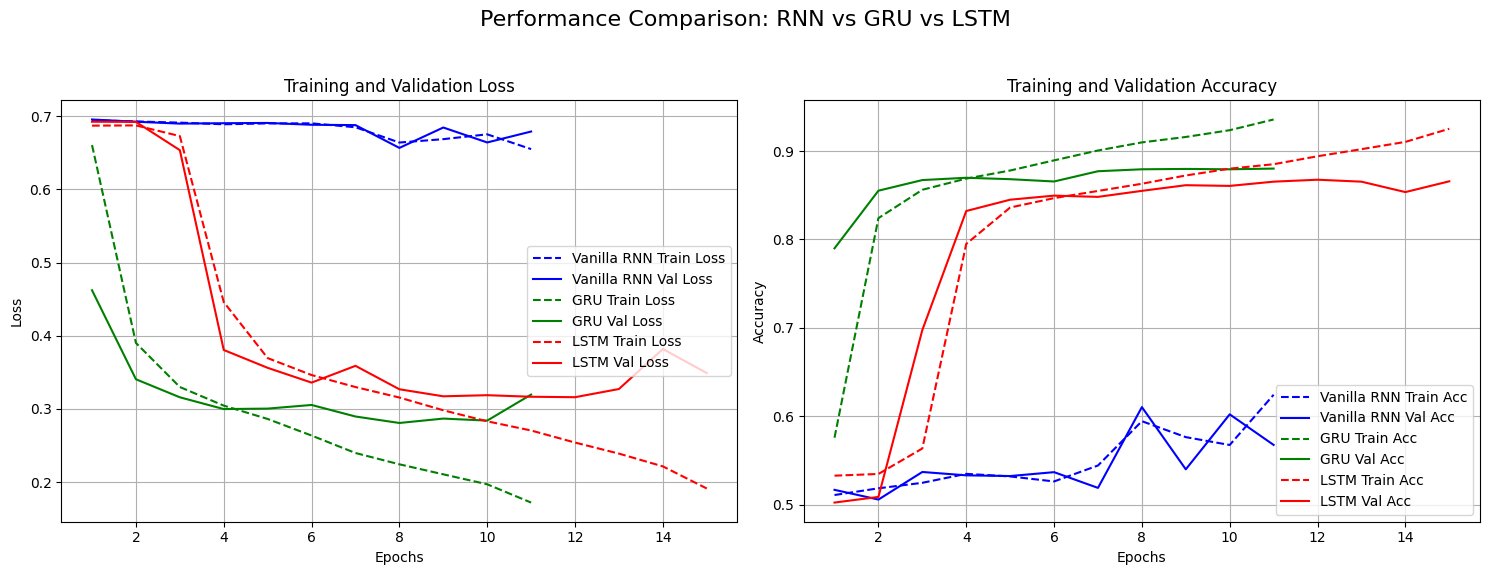

In [16]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

models = [
    ('Vanilla RNN', rnn_history),
    ('GRU', gru_history),
    ('LSTM', lstm_history)
]
colors = ['blue', 'green', 'red']

# Plot Loss
for i, (name, hist) in enumerate(models):
    epochs = range(1, len(hist['train_loss']) + 1)
    ax1.plot(epochs, hist['train_loss'], label=f'{name} Train Loss', color=colors[i], linestyle='--')
    ax1.plot(epochs, hist['val_loss'], label=f'{name} Val Loss', color=colors[i], linestyle='-')

ax1.set_title('Training and Validation Loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# Plot Accuracy
for i, (name, hist) in enumerate(models):
    epochs = range(1, len(hist['train_acc']) + 1)
    ax2.plot(epochs, hist['train_acc'], label=f'{name} Train Acc', color=colors[i], linestyle='--')
    ax2.plot(epochs, hist['val_acc'], label=f'{name} Val Acc', color=colors[i], linestyle='-')

ax2.set_title('Training and Validation Accuracy')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)

plt.suptitle('Performance Comparison: RNN vs GRU vs LSTM', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()